# Fetal Health Risk Model Training

**Novelle — AI-Powered Maternal Health Risk Support Platform**

This notebook trains the fetal health risk prediction model using LightGBM.

## Model Overview
- **Target**: Fetal health risk level (LOW / MEDIUM / HIGH)
- **Input Features**: Fetal movement, pregnancy week, maternal factors
- **Algorithm**: LightGBM Classifier
- **Explainability**: SHAP values for feature importance

---

In [ ]:
# Install dependencies (run once)
# !pip install pandas numpy scikit-learn xgboost lightgbm shap imbalanced-learn matplotlib seaborn joblib

## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import shap
import joblib

print("✅ Libraries loaded successfully")
print(f"   LightGBM version: {lgb.__version__}")

✅ Libraries loaded successfully
   LightGBM version: 4.6.0


## 2. Load Data

In [14]:
# Paths
DATA_DIR = Path('/content/datasets')
MODEL_DIR = Path('/content/models')
REPORT_DIR = Path('/content/reports')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load CTG (Cardiotocography) Fetal Health Dataset
df = pd.read_csv(DATA_DIR / 'fetal_health.csv')

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nOriginal Fetal Health Distribution (1=Normal, 2=Suspect, 3=Pathological):")
print(df['fetal_health'].value_counts().sort_index())
df.head()

Records: 2,126
Columns: ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'histogram_tendency', 'fetal_health']

Original Fetal Health Distribution (1=Normal, 2=Suspect, 3=Pathological):
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


## 3. Exploratory Data Analysis

In [15]:
# Data Cleaning: Map numeric labels to categorical
label_map = {1.0: 'LOW', 2.0: 'MEDIUM', 3.0: 'HIGH'}
df['risk_label'] = df['fetal_health'].map(label_map)

print("=" * 50)
print("CTG FETAL HEALTH DATASET INFO")
print("=" * 50)
print(df.info())
print("\n" + "=" * 50)
print("Cleaned Risk Distribution:")
print("=" * 50)
print(df['risk_label'].value_counts())

CTG FETAL HEALTH DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 23 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_val

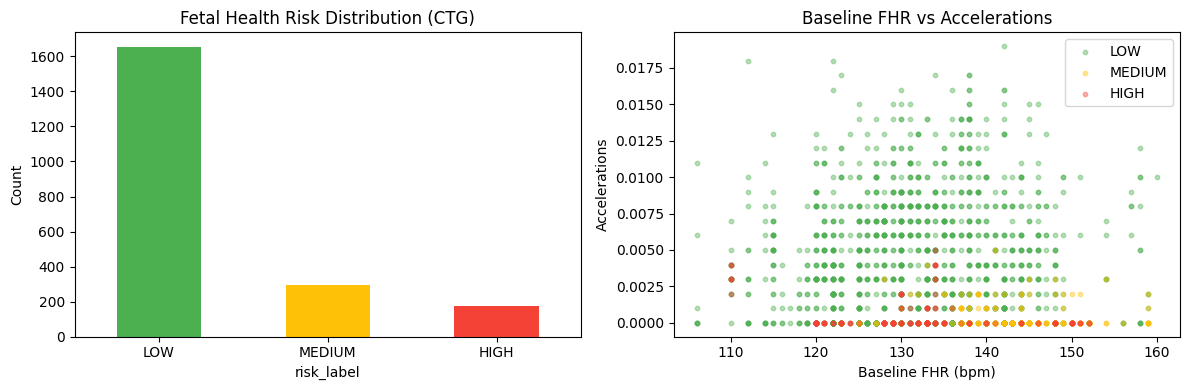

In [16]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk label distribution
risk_counts = df['risk_label'].value_counts()
colors = {'LOW': '#4CAF50', 'MEDIUM': '#FFC107', 'HIGH': '#F44336'}
risk_counts.plot(kind='bar', ax=axes[0], color=[colors.get(x, '#666') for x in risk_counts.index])
axes[0].set_title('Fetal Health Risk Distribution (CTG)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Baseline FHR vs Accelerations by risk
for label in ['LOW', 'MEDIUM', 'HIGH']:
    if label in df['risk_label'].values:
        subset = df[df['risk_label'] == label]
        axes[1].scatter(subset['baseline value'], subset['accelerations'],
                       alpha=0.4, label=label, color=colors[label], s=10)
axes[1].set_title('Baseline FHR vs Accelerations')
axes[1].set_xlabel('Baseline FHR (bpm)')
axes[1].set_ylabel('Accelerations')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fetal_health_eda.png', dpi=150)
plt.show()

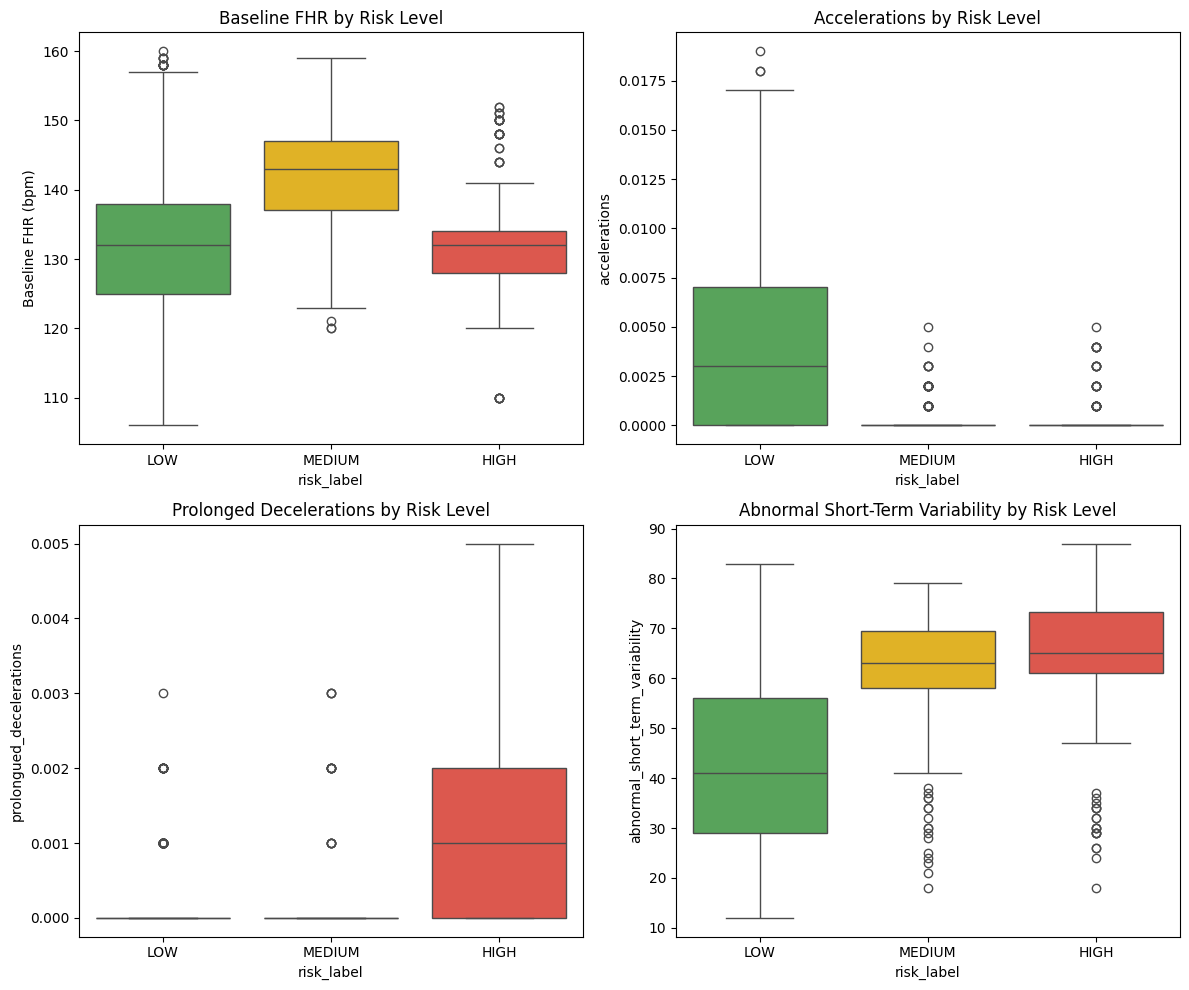

In [17]:
# Key CTG features by risk level
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Baseline FHR
sns.boxplot(data=df, x='risk_label', y='baseline value', palette=colors, ax=axes[0, 0], order=['LOW', 'MEDIUM', 'HIGH'])
axes[0, 0].set_title('Baseline FHR by Risk Level')
axes[0, 0].set_ylabel('Baseline FHR (bpm)')

# Accelerations
sns.boxplot(data=df, x='risk_label', y='accelerations', palette=colors, ax=axes[0, 1], order=['LOW', 'MEDIUM', 'HIGH'])
axes[0, 1].set_title('Accelerations by Risk Level')

# Prolonged Decelerations
sns.boxplot(data=df, x='risk_label', y='prolongued_decelerations', palette=colors, ax=axes[1, 0], order=['LOW', 'MEDIUM', 'HIGH'])
axes[1, 0].set_title('Prolonged Decelerations by Risk Level')

# Abnormal Short-Term Variability
sns.boxplot(data=df, x='risk_label', y='abnormal_short_term_variability', palette=colors, ax=axes[1, 1], order=['LOW', 'MEDIUM', 'HIGH'])
axes[1, 1].set_title('Abnormal Short-Term Variability by Risk Level')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'fetal_ctg_features.png', dpi=150)
plt.show()

## 4. Feature Engineering

In [18]:
# Feature Engineering for CTG Data
# The dataset already has rich features - we'll add a few derived features

# Total decelerations
df['total_decelerations'] = df['light_decelerations'] + df['severe_decelerations'] + df['prolongued_decelerations']

# Deceleration severity ratio
df['decel_severity_ratio'] = np.where(
    df['total_decelerations'] > 0,
    (df['severe_decelerations'] + df['prolongued_decelerations']) / df['total_decelerations'],
    0
)

# Variability score (combination of short and long term)
df['variability_score'] = (df['mean_value_of_short_term_variability'] +
                           df['mean_value_of_long_term_variability']) / 2

# Abnormal variability combined
df['abnormal_variability'] = (df['abnormal_short_term_variability'] +
                              df['percentage_of_time_with_abnormal_long_term_variability']) / 2

# Histogram statistics derived
df['histogram_range'] = df['histogram_max'] - df['histogram_min']
df['histogram_skewness'] = df['histogram_mean'] - df['histogram_median']

# Reactivity score (accelerations relative to baseline)
df['reactivity_score'] = df['accelerations'] * 1000  # Scale for better model learning

print(f"Engineered features added. Total columns: {len(df.columns)}")
print(f"\nNew features: total_decelerations, decel_severity_ratio, variability_score,")
print(f"              abnormal_variability, histogram_range, histogram_skewness, reactivity_score")
df.head()

Engineered features added. Total columns: 30

New features: total_decelerations, decel_severity_ratio, variability_score,
              abnormal_variability, histogram_range, histogram_skewness, reactivity_score


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_tendency,fetal_health,risk_label,total_decelerations,decel_severity_ratio,variability_score,abnormal_variability,histogram_range,histogram_skewness,reactivity_score
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,1.0,2.0,MEDIUM,0.000,0.0,1.45,58.0,64.0,16.0,0.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,0.0,1.0,LOW,0.003,0.0,6.25,8.5,130.0,-4.0,6.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,0.0,1.0,LOW,0.003,0.0,7.75,8.0,130.0,-3.0,3.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,1.0,1.0,LOW,0.003,0.0,12.70,8.0,117.0,-3.0,3.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,1.0,1.0,LOW,0.000,0.0,11.15,8.0,117.0,-2.0,7.0


## 5. Prepare Training Data

In [19]:
# Define features for CTG-based fetal health prediction
FEATURE_COLS = [
    # Original CTG features
    'baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions',
    'light_decelerations', 'severe_decelerations', 'prolongued_decelerations',
    'abnormal_short_term_variability', 'mean_value_of_short_term_variability',
    'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability',

    # Histogram features
    'histogram_width', 'histogram_min', 'histogram_max',
    'histogram_number_of_peaks', 'histogram_number_of_zeroes',
    'histogram_mode', 'histogram_mean', 'histogram_median',
    'histogram_variance', 'histogram_tendency',

    # Engineered features
    'total_decelerations', 'decel_severity_ratio', 'variability_score',
    'abnormal_variability', 'histogram_range', 'histogram_skewness', 'reactivity_score'
]

# Prepare X and y
X = df[FEATURE_COLS].copy()
y = df['risk_label'].copy()

# Handle missing values
X = X.fillna(X.median())

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(['LOW', 'MEDIUM', 'HIGH'])
y_encoded = label_encoder.transform(y)

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nClass distribution:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {(y_encoded == i).sum()} ({(y_encoded == i).mean()*100:.1f}%)")

Features: 28
Samples: 2126

Class distribution:
  HIGH: 176 (8.3%)
  LOW: 1655 (77.8%)
  MEDIUM: 295 (13.9%)


In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Train set: 1700 samples
Test set: 426 samples


In [21]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for LightGBM (preserves feature names)
X_train_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_df, y_train)

print(f"After SMOTE: {len(X_train_balanced)} samples")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {(y_train_balanced == i).sum()}")

After SMOTE: 3969 samples
  HIGH: 1323
  LOW: 1323
  MEDIUM: 1323


## 6. Model Training - LightGBM

In [22]:
# LightGBM with GPU acceleration (fast training)
import time

print("=" * 60)
print("LIGHTGBM MODEL TRAINING (GPU)")
print("=" * 60)

print("\n📋 Configuration:")
print("   - Algorithm: LightGBM (Gradient Boosting)")
print("   - Device: GPU (CUDA)")
print("   - Objective: Multiclass classification")

# Create model with GPU support
best_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    boosting_type='gbdt',
    device='gpu',              # Enable GPU
    gpu_platform_id=0,
    gpu_device_id=0,
    num_leaves=50,
    max_depth=7,
    n_estimators=200,
    learning_rate=0.1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train
print(f"\n🔄 Training LightGBM on GPU...")
print(f"   - Training samples: {len(X_train_balanced):,}")
print(f"   - Features: {X_train_balanced.shape[1]}")

start_time = time.time()

try:
    best_model.fit(X_train_balanced, y_train_balanced)
    elapsed = time.time() - start_time
    print(f"\n✅ GPU training completed!")
    print(f"   - Training time: {elapsed:.2f} seconds")
except Exception as e:
    print(f"\n⚠️  GPU not available, falling back to CPU: {e}")
    # Fallback to CPU
    best_model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        boosting_type='gbdt',
        num_leaves=50,
        max_depth=7,
        n_estimators=200,
        learning_rate=0.1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    best_model.fit(X_train_balanced, y_train_balanced)
    elapsed = time.time() - start_time
    print(f"✅ CPU training completed in {elapsed:.2f} seconds")

LIGHTGBM MODEL TRAINING (GPU)

📋 Configuration:
   - Algorithm: LightGBM (Gradient Boosting)
   - Device: GPU (CUDA)
   - Objective: Multiclass classification

🔄 Training LightGBM on GPU...
   - Training samples: 3,969
   - Features: 28

✅ GPU training completed!
   - Training time: 8.00 seconds


In [24]:
# Model parameters used
print("\n" + "=" * 50)
print("MODEL PARAMETERS")
print("=" * 50)
params_used = {
    'num_leaves': 50,
    'max_depth': 7,
    'n_estimators': 200,
    'learning_rate': 0.1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'device': 'gpu'
}
for param, value in params_used.items():
    print(f"  {param}: {value}")


MODEL PARAMETERS
  num_leaves: 50
  max_depth: 7
  n_estimators: 200
  learning_rate: 0.1
  min_child_samples: 20
  subsample: 0.8
  colsample_bytree: 0.8
  device: gpu


## 7. Model Evaluation

In [25]:
# Predictions
y_pred = best_model.predict(X_test_df)
y_pred_proba = best_model.predict_proba(X_test_df)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# AUC-ROC
try:
    auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
except:
    auc_roc = 0.0

print("\n" + "=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC-ROC:   {auc_roc:.4f}")


MODEL EVALUATION METRICS
  Accuracy:  0.9671
  Precision: 0.9679
  Recall:    0.9671
  F1 Score:  0.9673
  AUC-ROC:   0.9942


In [26]:
# Classification report
print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HIGH       0.91      0.89      0.90        35
         LOW       0.99      0.98      0.98       332
      MEDIUM       0.89      0.95      0.92        59

    accuracy                           0.97       426
   macro avg       0.93      0.94      0.93       426
weighted avg       0.97      0.97      0.97       426



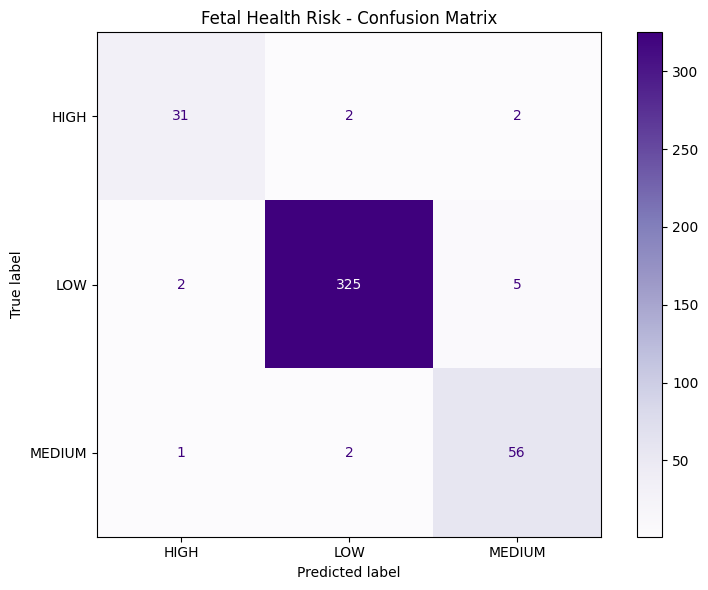

In [27]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Purples', values_format='d')
plt.title('Fetal Health Risk - Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'fetal_health_confusion_matrix.png', dpi=150)
plt.show()

## 8. Feature Importance & SHAP Analysis

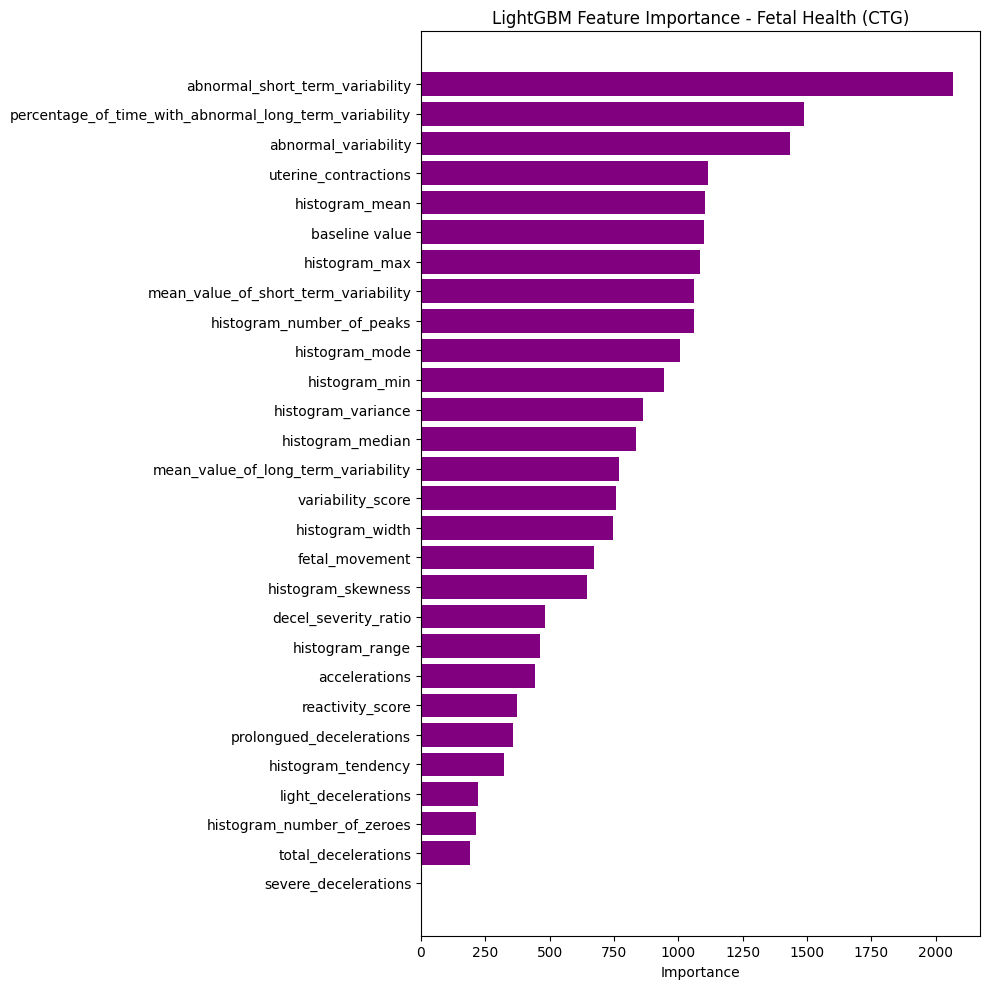

In [28]:
# Feature importance from LightGBM
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='purple')
plt.xlabel('Importance')
plt.title('LightGBM Feature Importance - Fetal Health (CTG)')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'fetal_health_feature_importance.png', dpi=150)
plt.show()

Computing SHAP values (this may take a moment)...


<Figure size 1200x1000 with 0 Axes>

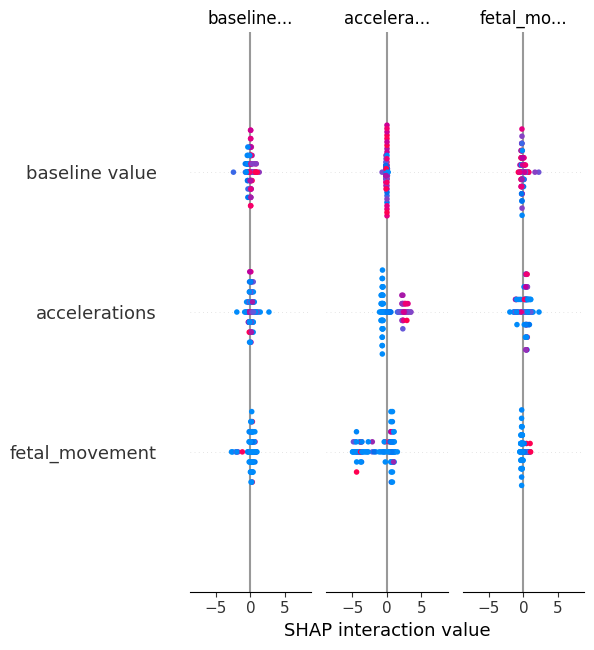

In [29]:
# SHAP values
print("Computing SHAP values (this may take a moment)...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df.iloc[:100])

# SHAP summary plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_df.iloc[:100], feature_names=FEATURE_COLS,
                  class_names=label_encoder.classes_, show=False)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'fetal_health_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Model Artifacts

In [30]:
# Save model, scaler, and encoder
joblib.dump(best_model, MODEL_DIR / 'fetal_health_lgbm.joblib')
joblib.dump(scaler, MODEL_DIR / 'fetal_health_scaler.joblib')
joblib.dump(label_encoder, MODEL_DIR / 'fetal_health_label_encoder.joblib')

# Save feature columns for inference
with open(MODEL_DIR / 'fetal_health_features.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("✅ Model artifacts saved:")
print(f"   - {MODEL_DIR / 'fetal_health_lgbm.joblib'}")
print(f"   - {MODEL_DIR / 'fetal_health_scaler.joblib'}")
print(f"   - {MODEL_DIR / 'fetal_health_label_encoder.joblib'}")
print(f"   - {MODEL_DIR / 'fetal_health_features.json'}")

✅ Model artifacts saved:
   - /content/models/fetal_health_lgbm.joblib
   - /content/models/fetal_health_scaler.joblib
   - /content/models/fetal_health_label_encoder.joblib
   - /content/models/fetal_health_features.json


In [32]:
# Save evaluation metrics
metrics = {
    'fetal_health': {
        'model': 'LightGBM',
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4),
        'auc_roc': round(auc_roc, 4),
        'best_params': params_used,
        'feature_columns': FEATURE_COLS,
        'dataset': 'CTG Fetal Health Dataset'
    }
}

# Load existing or create new
metrics_file = REPORT_DIR / 'evaluation_metrics.json'
if metrics_file.exists():
    with open(metrics_file, 'r') as f:
        all_metrics = json.load(f)
    all_metrics.update(metrics)
else:
    all_metrics = metrics

with open(metrics_file, 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f"\n✅ Metrics saved to {metrics_file}")


✅ Metrics saved to /content/reports/evaluation_metrics.json


## 10. Model Inference Test

In [33]:
def predict_fetal_risk(baseline_fhr, accelerations, fetal_movement, uterine_contractions,
                       light_decelerations=0, severe_decelerations=0, prolongued_decelerations=0,
                       abnormal_short_term_variability=0, mean_short_term_variability=1,
                       percentage_abnormal_long_term=0, mean_long_term_variability=5,
                       histogram_width=100, histogram_min=60, histogram_max=160,
                       histogram_peaks=3, histogram_zeroes=0, histogram_mode=140,
                       histogram_mean=135, histogram_median=140, histogram_variance=10,
                       histogram_tendency=0):
    """Predict fetal health risk from CTG features."""
    # Load artifacts
    model = joblib.load(MODEL_DIR / 'fetal_health_lgbm.joblib')
    scaler_loaded = joblib.load(MODEL_DIR / 'fetal_health_scaler.joblib')
    encoder = joblib.load(MODEL_DIR / 'fetal_health_label_encoder.joblib')

    # Engineered features
    total_decelerations = light_decelerations + severe_decelerations + prolongued_decelerations
    decel_severity_ratio = ((severe_decelerations + prolongued_decelerations) / total_decelerations
                           if total_decelerations > 0 else 0)
    variability_score = (mean_short_term_variability + mean_long_term_variability) / 2
    abnormal_variability = (abnormal_short_term_variability + percentage_abnormal_long_term) / 2
    histogram_range = histogram_max - histogram_min
    histogram_skewness = histogram_mean - histogram_median
    reactivity_score = accelerations * 1000

    features = np.array([[
        baseline_fhr, accelerations, fetal_movement, uterine_contractions,
        light_decelerations, severe_decelerations, prolongued_decelerations,
        abnormal_short_term_variability, mean_short_term_variability,
        percentage_abnormal_long_term, mean_long_term_variability,
        histogram_width, histogram_min, histogram_max,
        histogram_peaks, histogram_zeroes,
        histogram_mode, histogram_mean, histogram_median,
        histogram_variance, histogram_tendency,
        total_decelerations, decel_severity_ratio, variability_score,
        abnormal_variability, histogram_range, histogram_skewness, reactivity_score
    ]])

    features_scaled = scaler_loaded.transform(features)
    features_df = pd.DataFrame(features_scaled, columns=FEATURE_COLS)

    prediction = model.predict(features_df)[0]
    probabilities = model.predict_proba(features_df)[0]

    risk_label = encoder.inverse_transform([prediction])[0]
    confidence = probabilities[prediction]

    return {
        'risk_level': risk_label,
        'confidence': round(confidence, 3),
        'probabilities': {cls: round(prob, 3) for cls, prob in zip(encoder.classes_, probabilities)}
    }

# Test cases
print("\n" + "=" * 60)
print("INFERENCE TEST - CTG FETAL HEALTH PREDICTION")
print("=" * 60)

# Normal (LOW risk) - good baseline, accelerations, no decelerations
result = predict_fetal_risk(
    baseline_fhr=130, accelerations=0.006, fetal_movement=0.003, uterine_contractions=0.005,
    abnormal_short_term_variability=12, mean_short_term_variability=2.5
)
print(f"\nNormal CTG: Baseline=130, Accelerations=0.006, Normal variability")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")

# Suspect (MEDIUM risk) - some abnormalities
result = predict_fetal_risk(
    baseline_fhr=145, accelerations=0.002, fetal_movement=0.001, uterine_contractions=0.004,
    light_decelerations=0.002, abnormal_short_term_variability=60
)
print(f"\nSuspect CTG: Baseline=145, Low accelerations, Some abnormal variability")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")

# Pathological (HIGH risk) - severe abnormalities
result = predict_fetal_risk(
    baseline_fhr=160, accelerations=0, fetal_movement=0, uterine_contractions=0.008,
    light_decelerations=0, severe_decelerations=0.001, prolongued_decelerations=0.002,
    abnormal_short_term_variability=85, percentage_abnormal_long_term=90
)
print(f"\nPathological CTG: Tachycardia, No accelerations, Severe decelerations")
print(f"  → Prediction: {result['risk_level']} (confidence: {result['confidence']})")


INFERENCE TEST - CTG FETAL HEALTH PREDICTION

Normal CTG: Baseline=130, Accelerations=0.006, Normal variability
  → Prediction: LOW (confidence: 1.0)

Suspect CTG: Baseline=145, Low accelerations, Some abnormal variability
  → Prediction: LOW (confidence: 1.0)

Pathological CTG: Tachycardia, No accelerations, Severe decelerations
  → Prediction: HIGH (confidence: 0.991)


---

## Summary

✅ **Fetal Health Risk Model trained successfully!**

| Metric | Value |
|--------|-------|
| Algorithm | LightGBM |
| Dataset | CTG Fetal Health (2126 records) |
| Features | 28 (21 original + 7 engineered) |
| Target | LOW (Normal) / MEDIUM (Suspect) / HIGH (Pathological) |

### Key CTG Indicators
- **Baseline FHR**: Normal 110-160 bpm
- **Accelerations**: Reactive pattern indicates good health
- **Decelerations**: Severe/prolonged = concerning
- **Variability**: Low variability = potential distress
- **Histogram Features**: Distribution of FHR values

### Model Artifacts Saved
- `fetal_health_lgbm.joblib` — Trained LightGBM model
- `fetal_health_scaler.joblib` — StandardScaler
- `fetal_health_label_encoder.joblib` — LabelEncoder
- `fetal_health_features.json` — Feature columns list

---

⚠️ **Disclaimer**: This model predicts risk likelihood from CTG data only — NOT a medical diagnosis. Always consult healthcare professionals.